# Tutorial 10 — Energy use and processor load

## 1. Problem / context

Facilities want to know how daily energy use (kWh) changes with CPU load (%) on a set of one-day benchmark runs. The file is `energy_load.csv`. Each row is one day: that is the observational unit. The quantitative response is `energy_kwh`; the quantitative predictor is `cpu_load_pct`.

This is a **statistics** tutorial: a conditional-mean model, residuals, inference for the slope, and the distinction between a mean-response interval and a prediction interval. Brooks Chapter 10 is the theory. We use **statsmodels**. We do not use scikit-learn, train/test splits, or a machine-learning framing.

## 2. What we will compute

$$
Y=\beta_0+\beta_1 x+\varepsilon,
\qquad
\hat y=\hat\beta_0+\hat\beta_1 x.
$$

$\hat y$ is the fitted mean energy at load $x$. A residual is $y_i-\hat y_i$.

- The **slope** $\beta_1$ is the change in mean energy (kWh) associated with a one percentage-point difference in load. The **intercept** is the mean energy at 0% load; that point is outside the observed range, so we will not treat $\hat\beta_0$ as an operating figure.
- **Pearson** $r$ measures direction and strength of **linear** association, from $-1$ to $1$. There is no universal cutoff for “strong”. Correlation is not causation.
- $R^2$ is the fraction of observed squared variation in $y$ about $\bar y$ accounted for by the fitted line. It is not the probability that the model is correct, not causation, and not a universal measure of prediction quality.
- For simple linear regression **with an intercept**, $R^2=r^2$. That identity need not hold for a no-intercept fit.
- Residual-versus-fitted, residual-versus-order, and a QQ-plot of residuals address linearity, constant spread, and the normal-error approximation used for $t$ intervals. They do not establish representative sampling or independence of days.
- An unusual point is investigated, not deleted automatically.
- At a load $x_0$ **inside the observed range**, a confidence interval for the mean response is narrower than a prediction interval for one new day. We do not extrapolate outside the observed loads without a defensible engineering model.

## 3. Python implementation


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr, probplot
import statsmodels.api as sm

candidates = [Path("data"), Path("../data"), Path.cwd() / "data"]
DATA = next(p for p in candidates if p.exists())
df = pd.read_csv(DATA / "energy_load.csv")
print(df.head())
print(df[["cpu_load_pct", "energy_kwh"]].describe())
print("observed load range (%):", df["cpu_load_pct"].min(), "to", df["cpu_load_pct"].max())


   day  cpu_load_pct  energy_kwh
0    1         17.30      13.591
1    2         17.54      19.260
2    3         19.82      20.631
3    4         20.68      22.873
4    5         21.14      16.008
       cpu_load_pct  energy_kwh
count     40.000000   40.000000
mean      53.370000   32.343250
std       23.099234   10.447586
min       17.300000   13.591000
25%       34.122500   22.799000
50%       54.300000   30.454000
75%       73.177500   41.729500
max       92.710000   52.349000
observed load range (%): 17.3 to 92.71


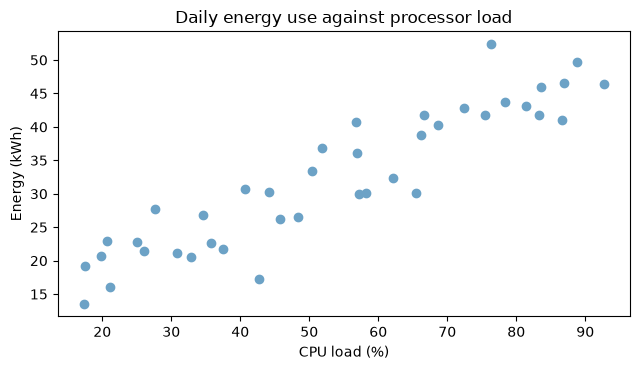

In [2]:
x = df["cpu_load_pct"]
y = df["energy_kwh"]
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.scatter(x, y, color="#6CA2C6")
ax.set_xlabel("CPU load (%)")
ax.set_ylabel("Energy (kWh)")
ax.set_title("Daily energy use against processor load")
plt.tight_layout()
plt.show()


In [3]:
X = sm.add_constant(x)
ols = sm.OLS(y, X).fit()
print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:             energy_kwh   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     209.6
Date:                Mon, 31 Aug 2026   Prob (F-statistic):           4.77e-17
Time:                        13:20:22   Log-Likelihood:                -112.62
No. Observations:                  40   AIC:                             229.2
Df Residuals:                      38   BIC:                             232.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           10.1340      1.668      6.074   

Extract the quantities we will report. Do not treat the software dump as the conclusion.


In [4]:
r, _ = pearsonr(x, y)
slope = ols.params["cpu_load_pct"]
slope_ci = ols.conf_int().loc["cpu_load_pct"]
print(f"intercept = {ols.params['const']:.3f} kWh  (x = 0% is outside the observed range)")
print(f"slope     = {slope:.4f} kWh per percentage point")
print(f"SE(slope) = {ols.bse['cpu_load_pct']:.4f}")
print(f"95% CI    = [{slope_ci.iloc[0]:.4f}, {slope_ci.iloc[1]:.4f}]")
print(f"t = {ols.tvalues['cpu_load_pct']:.2f}, df = {int(ols.df_resid)}, p = {ols.pvalues['cpu_load_pct']:.4g}")
print(f"residual SD s = {np.sqrt(ols.scale):.3f} kWh")
print(f"R-squared = {ols.rsquared:.3f}")
print(f"Pearson r = {r:.3f}, r^2 = {r**2:.3f}")
print("R^2 equals r^2 for this intercept model?", np.isclose(ols.rsquared, r**2))


intercept = 10.134 kWh  (x = 0% is outside the observed range)
slope     = 0.4161 kWh per percentage point
SE(slope) = 0.0287
95% CI    = [0.3579, 0.4743]
t = 14.48, df = 38, p = 4.77e-17
residual SD s = 4.147 kWh
R-squared = 0.847
Pearson r = 0.920, r^2 = 0.847
R^2 equals r^2 for this intercept model? True


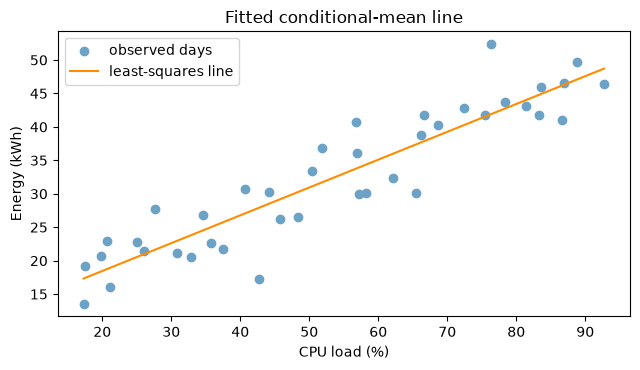

In [5]:
xx = np.linspace(x.min(), x.max(), 80)
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.scatter(x, y, color="#6CA2C6", label="observed days")
ax.plot(xx, ols.predict(sm.add_constant(xx)), color="#FF8C00", label="least-squares line")
ax.set_xlabel("CPU load (%)")
ax.set_ylabel("Energy (kWh)")
ax.set_title("Fitted conditional-mean line")
ax.legend()
plt.tight_layout()
plt.show()


### Diagnostics


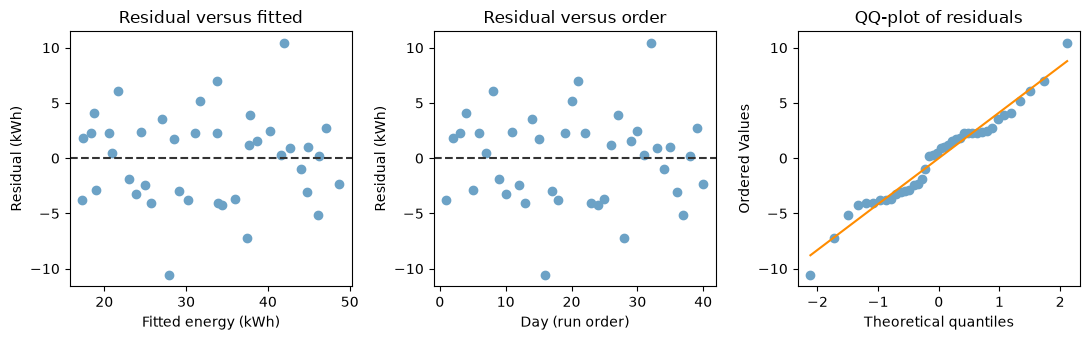

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
axes[0].scatter(ols.fittedvalues, ols.resid, color="#6CA2C6")
axes[0].axhline(0, color="0.2", linestyle="--")
axes[0].set_xlabel("Fitted energy (kWh)")
axes[0].set_ylabel("Residual (kWh)")
axes[0].set_title("Residual versus fitted")

axes[1].scatter(df["day"], ols.resid, color="#6CA2C6")
axes[1].axhline(0, color="0.2", linestyle="--")
axes[1].set_xlabel("Day (run order)")
axes[1].set_ylabel("Residual (kWh)")
axes[1].set_title("Residual versus order")

probplot(ols.resid, dist="norm", plot=axes[2])
axes[2].get_lines()[0].set_markerfacecolor("#6CA2C6")
axes[2].get_lines()[0].set_markeredgecolor("#6CA2C6")
axes[2].get_lines()[1].set_color("#FF8C00")
axes[2].set_title("QQ-plot of residuals")
plt.tight_layout()
plt.show()


In [7]:
infl = ols.get_influence()
leverage = infl.hat_matrix_diag
cooks = infl.cooks_distance[0]
flag = np.argmax(cooks)
print(f"largest Cook's distance: day {int(df.loc[flag, 'day'])}, D = {cooks[flag]:.3f}, leverage = {leverage[flag]:.3f}")
print("Investigate an influential day; do not delete it automatically.")


largest Cook's distance: day 32, D = 0.177, leverage = 0.050
Investigate an influential day; do not delete it automatically.


Pause: if one day has large Cook’s distance, what would you check in the operations log before changing the model?

### Mean response versus one new day, at 70% load

70% lies inside the observed load range.


In [8]:
pred = ols.get_prediction([1, 70])
frame = pred.summary_frame(alpha=0.05)
print(frame[["mean", "mean_ci_lower", "mean_ci_upper", "obs_ci_lower", "obs_ci_upper"]])


        mean  mean_ci_lower  mean_ci_upper  obs_ci_lower  obs_ci_upper
0  39.263607      37.621038      40.906177     30.710172     47.817043


`mean_ci_*` is the 95% interval for the **mean** energy at 70% load. `obs_ci_*` is the wider 95% **prediction** interval for **one new day** at 70%.

A load of 5% or 110% is outside the observed range. We do not predict there from this line alone.

## 4. Interpretation

Follow the Chapter 10 eight-step workflow: population, unit, $y$, $x$, range; design; scatterplot; slope in kWh per percentage point; residual diagnostics and influence; slope interval, $t$, $p$, $s$, $R^2$; mean versus prediction interval; association versus causation.

The fitted slope describes an association in these benchmark days. It does not, by itself, prove that raising load **causes** energy to rise, even though that mechanism may be physically plausible. The design of the study, not the size of $R^2$, decides a causal claim.

## 5. Common mistakes / things to notice

- Interpreting the intercept at 0% load when 0% was never observed.
- Treating $R^2$ as the probability that the line is true, or as causation.
- Using a QQ-plot of raw $y$ instead of residuals.
- Deleting an influential point because it is inconvenient.
- Quoting the mean-response interval as if it were a prediction for one new day.
- Extrapolating outside the observed load range.
- Fitting with scikit-learn and then reporting a $p$-value that that library does not compute.

**Conclusion:** In this sample, mean energy increases with CPU load on a roughly linear scale. Report the slope in kWh per percentage point with its interval, $R^2$ as a description of squared variation, the residual SD as leftover day-to-day variation, and a prediction interval when the question is about **one new day**. Stay inside the observed load range.
